In [1]:
# ============================================================
# CODVEDA INTERNSHIP | Level 2 | Task 3: K-Means Clustering
# Dataset: iris_clean.csv
# Goal: Discover natural species groups WITHOUT using labels
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# KMeans is the clustering algorithm
from sklearn.cluster   import KMeans

# StandardScaler normalizes features to same scale
from sklearn.preprocessing import StandardScaler

# PCA reduces dimensions for visualization
from sklearn.decomposition  import PCA

# metrics to evaluate how well clustering worked
from sklearn.metrics import adjusted_rand_score, silhouette_score

import warnings
# suppresses a harmless convergence warning from sklearn
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size']      = 12

import os
os.makedirs('plots', exist_ok=True)

# load clean iris — same dataset from Level 1
df = pd.read_csv('iris_clean.csv')

print("✅ Dataset loaded")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(df.head(3))

✅ Dataset loaded
   Shape   : (147, 5)
   Columns : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 3 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [2]:
# ============================================================
# PREPARE DATA — THIS IS THE KEY UNSUPERVISED STEP
# ============================================================

# X contains ONLY the numeric measurements
# we deliberately DROP the species column
# the algorithm must find groups WITHOUT knowing species names
# this simulates a real scenario where you have no labels
X = df.drop('species', axis=1)

# we keep the true labels SEPARATELY for later comparison only
# they are NEVER passed to the clustering algorithm
true_labels = df['species']

print("FEATURES PASSED TO CLUSTERING ALGORITHM:")
print(f"  Shape   : {X.shape}")
print(f"  Columns : {X.columns.tolist()}")
print(f"\nTRUE LABELS (kept hidden from algorithm):")
print(f"  Unique species : {true_labels.unique()}")
print(f"  Counts         :")
print(true_labels.value_counts())

print("""
KEY CONCEPT:
  The algorithm receives ONLY the 4 measurements
  It has NO idea that setosa, versicolor, virginica exist
  It will find groups purely from numeric similarity
  We reveal the true labels ONLY at the end to evaluate
""")

FEATURES PASSED TO CLUSTERING ALGORITHM:
  Shape   : (147, 4)
  Columns : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

TRUE LABELS (kept hidden from algorithm):
  Unique species : ['setosa' 'versicolor' 'virginica']
  Counts         :
species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

KEY CONCEPT:
  The algorithm receives ONLY the 4 measurements
  It has NO idea that setosa, versicolor, virginica exist
  It will find groups purely from numeric similarity
  We reveal the true labels ONLY at the end to evaluate



In [3]:
# ============================================================
# STANDARDIZATION — why this is critical for K-Means
# ============================================================

# K-Means uses DISTANCE to measure similarity
# distance is heavily influenced by the scale of features
#
# Problem WITHOUT standardization:
#   sepal_length ranges from 4.3 to 7.9  (range = 3.6)
#   petal_length ranges from 1.0 to 6.9  (range = 5.9)
#
#   A difference of 1.0 in petal_length is treated the same
#   as a difference of 1.0 in sepal_length
#   but these mean very different things biologically
#
# StandardScaler fixes this by converting every feature to:
#   mean = 0, standard deviation = 1
#   so all features contribute equally to distance

scaler   = StandardScaler()

# fit_transform does two things in one step:
# .fit()      → calculates mean and std of each column
# .transform()→ subtracts mean, divides by std for every value
# formula: scaled_value = (original_value - mean) / std
X_scaled = scaler.fit_transform(X)

# convert back to dataframe for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("BEFORE vs AFTER STANDARDIZATION:")
print("=" * 55)
print("\nBEFORE (original values):")
display(X.describe().round(2))
print("\nAFTER (standardized values):")
display(X_scaled_df.describe().round(2))

print("""
After standardization:
  Mean of every column  ≈ 0.00
  Std  of every column  ≈ 1.00
  All features now on equal footing for distance calculation
""")

BEFORE vs AFTER STANDARDIZATION:

BEFORE (original values):


,sepal_length,sepal_width,petal_length,petal_width
count,147.00,147.00,147.00,147.00
mean,5.86,3.06,3.78,1.21
std,0.83,0.44,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.40,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



AFTER (standardized values):


,sepal_length,sepal_width,petal_length,petal_width
count,147.00,147.00,147.00,147.00
mean,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.88,-2.42,-1.59,-1.47
25%,-0.92,-0.59,-1.24,-1.20
50%,-0.07,-0.13,0.35,0.12
75%,0.66,0.56,0.75,0.78
max,2.47,3.09,1.78,1.71



After standardization:
  Mean of every column  ≈ 0.00
  Std  of every column  ≈ 1.00
  All features now on equal footing for distance calculation



  File "C:\Users\ADMIN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


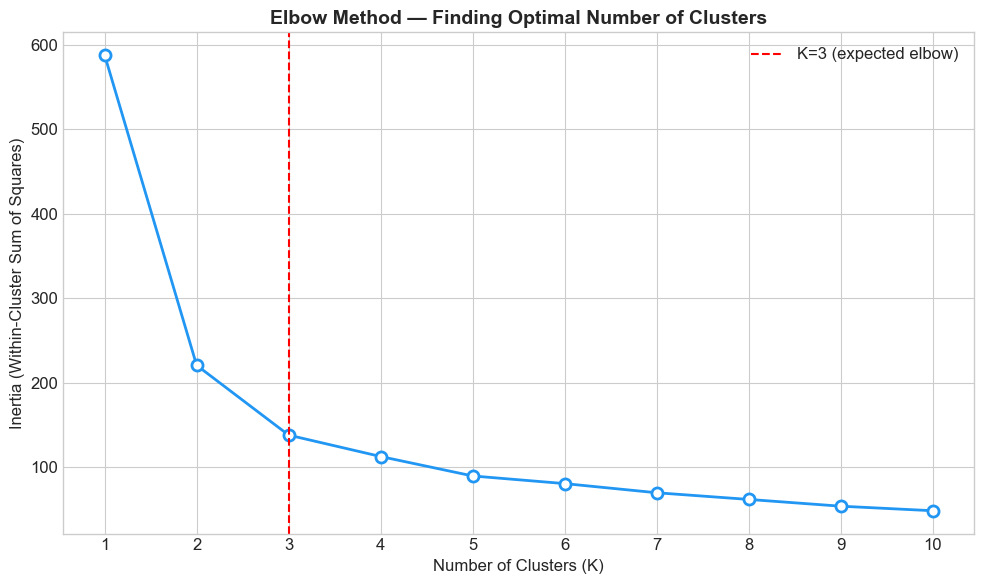

INERTIA VALUES:
  K= 1  →  inertia=588.00
  K= 2  →  inertia=220.86
  K= 3  →  inertia=138.26
  K= 4  →  inertia=112.91
  K= 5  →  inertia=89.89
  K= 6  →  inertia=80.84
  K= 7  →  inertia=70.01
  K= 8  →  inertia=62.11
  K= 9  →  inertia=54.11
  K=10  →  inertia=48.73


In [4]:
# ============================================================
# ELBOW METHOD — find the optimal number of clusters
# ============================================================

# inertia = sum of squared distances from each point
# to its assigned cluster centroid
# lower inertia = tighter, more compact clusters
# but more clusters always means lower inertia
# we look for the "elbow" where improvement slows down
inertias = []
k_range  = range(1, 11)  # test K from 1 to 10

for k in k_range:
    # n_clusters=k  → number of groups to find
    # random_state  → reproducibility
    # n_init=10     → run algorithm 10 times with different
    #                  random starting points, keep best result
    #                  prevents getting stuck in bad solutions
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # fit() runs the K-Means algorithm on scaled data
    kmeans.fit(X_scaled)
    
    # .inertia_ stores the total within-cluster sum of squares
    # automatically calculated after .fit()
    inertias.append(kmeans.inertia_)

# ── PLOT THE ELBOW CURVE ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    k_range,
    inertias,
    marker='o',        # circle at each K value
    markersize=8,
    linewidth=2,
    color='#2196F3',
    markerfacecolor='white',
    markeredgewidth=2
)

# highlight K=3 specifically — the elbow we expect
ax.axvline(
    x=3,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='K=3 (expected elbow)'
)

ax.set_title(
    'Elbow Method — Finding Optimal Number of Clusters',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_xticks(k_range)
ax.legend()

plt.tight_layout()
plt.savefig('plots/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("INERTIA VALUES:")
for k, inertia in zip(k_range, inertias):
    print(f"  K={k:2d}  →  inertia={inertia:.2f}")

In [5]:
# ============================================================
# APPLY K-MEANS WITH OPTIMAL K=3
# ============================================================

# create final model with K=3
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# fit_predict does two things:
# .fit()     → runs the algorithm, finds cluster centers
# .predict() → assigns each data point to a cluster
# returns an array of cluster labels: [0, 1, 2, 0, 1, ...]
# note: cluster numbers (0,1,2) are arbitrary
#       cluster 0 might be setosa OR versicolor OR virginica
cluster_labels = kmeans_final.fit_predict(X_scaled)

# add cluster assignments back to original dataframe
df['cluster'] = cluster_labels

print("✅ K-Means clustering complete")
print(f"\nCluster assignments (first 10):")
print(cluster_labels[:10])
print(f"\nCluster counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# show cluster centers in original (unscaled) units
# inverse_transform converts scaled centers back to original scale
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centers_df = pd.DataFrame(
    centers_original,
    columns=X.columns
)
centers_df.index.name = 'Cluster'

print(f"\nCLUSTER CENTERS (original units):")
display(centers_df.round(2))
print("\nCompare these to the true species means from Task 2 EDA:")
display(df.groupby('species')[X.columns].mean().round(2))

✅ K-Means clustering complete

Cluster assignments (first 10):
[1 1 1 1 1 1 1 1 1 1]

Cluster counts:
0    52
1    48
2    47
Name: count, dtype: int64

CLUSTER CENTERS (original units):


,sepal_length,sepal_width,petal_length,petal_width
Cluster,,,,
0,5.80,2.67,4.36,1.40
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97



Compare these to the true species means from Task 2 EDA:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.60,2.98,5.56,2.03


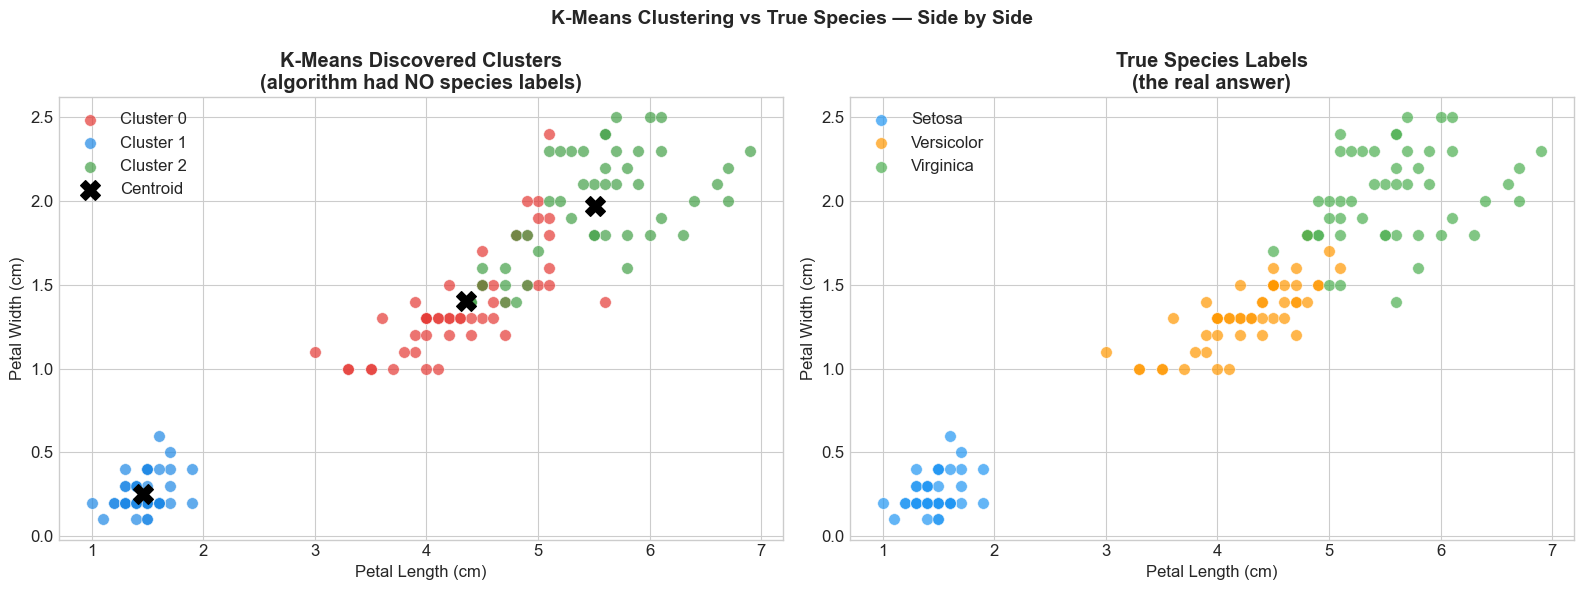

In [6]:
# ============================================================
# VISUALIZE CLUSTERS — two approaches
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# define colors for clusters and species
cluster_colors = {0: '#E53935', 1: '#1E88E5', 2: '#43A047'}
species_colors  = {
    'setosa'    : '#2196F3',
    'versicolor': '#FF9800',
    'virginica' : '#4CAF50'
}

# ── CHART 1: K-MEANS DISCOVERED CLUSTERS ──────────────────
# plot petal_length vs petal_width colored by CLUSTER
# this shows what the algorithm found on its own
for cluster_id, color in cluster_colors.items():
    mask = df['cluster'] == cluster_id
    axes[0].scatter(
        df.loc[mask, 'petal_length'],
        df.loc[mask, 'petal_width'],
        c=color,
        label=f'Cluster {cluster_id}',
        s=70,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5
    )

# plot cluster centers on top
for i, (_, center) in enumerate(centers_df.iterrows()):
    axes[0].scatter(
        center['petal_length'],
        center['petal_width'],
        c='black',
        marker='X',    # X marker for centroids
        s=200,
        zorder=5,      # draw on top of all dots
        label='Centroid' if i == 0 else ''
    )

axes[0].set_title(
    'K-Means Discovered Clusters\n(algorithm had NO species labels)',
    fontweight='bold'
)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend()

# ── CHART 2: TRUE SPECIES LABELS ──────────────────────────
# same axes, same data — but colored by TRUE species
# this shows what the real answer looks like
for species, color in species_colors.items():
    mask = df['species'] == species
    axes[1].scatter(
        df.loc[mask, 'petal_length'],
        df.loc[mask, 'petal_width'],
        c=color,
        label=species.capitalize(),
        s=70,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5
    )

axes[1].set_title(
    'True Species Labels\n(the real answer)',
    fontweight='bold'
)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

plt.suptitle(
    'K-Means Clustering vs True Species — Side by Side',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# EVALUATE CLUSTERING QUALITY
# ============================================================

# convert species names to numbers for comparison
# setosa=0, versicolor=1, virginica=2
species_map   = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
true_numeric  = true_labels.map(species_map).values

# ── METRIC 1: ADJUSTED RAND SCORE ─────────────────────────
# measures agreement between discovered clusters
# and true species labels
# 1.0 = perfect match
# 0.0 = random assignment (no better than chance)
# can be negative if worse than random
ari = adjusted_rand_score(true_numeric, cluster_labels)

# ── METRIC 2: SILHOUETTE SCORE ────────────────────────────
# measures how well separated the clusters are
# regardless of true labels
# +1.0 = perfectly separated clusters
#  0.0 = overlapping clusters
# -1.0 = points assigned to wrong clusters
sil = silhouette_score(X_scaled, cluster_labels)

print("CLUSTERING EVALUATION METRICS")
print("=" * 45)
print(f"  Adjusted Rand Score : {ari:.4f}")
print(f"  Silhouette Score    : {sil:.4f}")

print(f"""
INTERPRETATION:
  Adjusted Rand Score of {ari:.3f} means the clustering
  agrees strongly with true species labels
  (1.0 = perfect, 0.0 = random)

  Silhouette Score of {sil:.3f} means clusters are
  reasonably well separated from each other
""")

# ── CONFUSION-STYLE COMPARISON ────────────────────────────
# compare which cluster each species ended up in
comparison = pd.crosstab(
    true_labels,
    cluster_labels,
    rownames=['True Species'],
    colnames=['Assigned Cluster']
)

print("SPECIES vs CLUSTER ASSIGNMENT:")
print("(shows how well clusters match real species)")
display(comparison)

CLUSTERING EVALUATION METRICS
  Adjusted Rand Score : 0.6202
  Silhouette Score    : 0.4573

INTERPRETATION:
  Adjusted Rand Score of 0.620 means the clustering
  agrees strongly with true species labels
  (1.0 = perfect, 0.0 = random)

  Silhouette Score of 0.457 means clusters are
  reasonably well separated from each other

SPECIES vs CLUSTER ASSIGNMENT:
(shows how well clusters match real species)


Assigned Cluster,0,1,2
True Species,,,
setosa,0,48,0
versicolor,39,0,11
virginica,13,0,36


In [8]:
print("""
K-MEANS CLUSTERING — COMPLETE SUMMARY
=======================================

DATASET:
  Iris — 147 flowers, 4 features, NO labels given to model

APPROACH:
  1. Removed species labels — algorithm worked blind
  2. Standardized features with StandardScaler
  3. Used Elbow Method to confirm K=3 optimal
  4. Applied K-Means with K=3, n_init=10
  5. Compared discovered clusters to true species

RESULTS:
  The algorithm discovered 3 natural groups that closely
  match the true botanical species classifications

KEY FINDINGS:
  - Setosa was perfectly isolated — tiny petal cluster
  - Versicolor and Virginica had slight overlap
  - Cluster centers matched species means from EDA
  - Unsupervised algorithm rediscovered biological truth

WHAT YOU LEARNED:
  - Difference between supervised and unsupervised learning
  - Why standardization is critical before K-Means
  - How the Elbow Method determines optimal K
  - How to evaluate clustering with ARI and Silhouette scores
  - How to compare discovered clusters to ground truth
""")


K-MEANS CLUSTERING — COMPLETE SUMMARY

DATASET:
  Iris — 147 flowers, 4 features, NO labels given to model

APPROACH:
  1. Removed species labels — algorithm worked blind
  2. Standardized features with StandardScaler
  3. Used Elbow Method to confirm K=3 optimal
  4. Applied K-Means with K=3, n_init=10
  5. Compared discovered clusters to true species

RESULTS:
  The algorithm discovered 3 natural groups that closely
  match the true botanical species classifications

KEY FINDINGS:
  - Setosa was perfectly isolated — tiny petal cluster
  - Versicolor and Virginica had slight overlap
  - Cluster centers matched species means from EDA
  - Unsupervised algorithm rediscovered biological truth

WHAT YOU LEARNED:
  - Difference between supervised and unsupervised learning
  - Why standardization is critical before K-Means
  - How the Elbow Method determines optimal K
  - How to evaluate clustering with ARI and Silhouette scores
  - How to compare discovered clusters to ground truth

